# Banking Financial Health Classification: Model Training & Evaluation

**Project:** ARB Apex Bank - Rural Banking Risk Assessment System   

---

## Objective
Build and evaluate classification models to predict bank financial health status with:
1. Multiple algorithms (Logistic Regression, Random Forest, XGBoost, SVM, KNN)
2. Hyperparameter tuning using GridSearchCV
3. 5-fold stratified cross-validation
4. Performance evaluation prioritizing recall (≥80%)
5. Model interpretation using feature importance and SHAP values


## Model Training Pipeline
1. Load preprocessed data
2. Train baseline models with default parameters
3. Perform 5-fold cross-validation
4. Hyperparameter tuning for top performers
5. Final model selection based on recall
6. Comprehensive evaluation on test set
7. Model interpretation (feature importance, SHAP)

In [1]:
%pip install shap numpy==1.26.4

Note: you may need to restart the kernel to use updated packages.


# Setup and Libraries 


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import joblib

# Scikit-learn imports
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score
)

# SHAP for model interpretation
import shap

# Configuration
warnings.filterwarnings('ignore')
np.random.seed(42)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
#Load preprocessed data 
data_dir = 'data/processed'
print("Loading preprocessed datasets...")
print("-"* 70)

#Load training data(SMOTE-balanced)
X_train = np.load(f'{data_dir}/X_train_resampled.npy')
y_train = np.load(f'{data_dir}/y_train_resampled.npy')

#Load test data (original distribution)
X_test = np.load(f'{data_dir}/X_test_processed.npy')
y_test = np.load(f'{data_dir}/y_test.npy')

#Load features 
feature_names = pd.read_csv(f'{data_dir}/feature_names.csv')

print(f"Training set loaded: {X_train.shape}")
print(f"Test set loaded: {X_test.shape}")
print(f"Feature names loaded: {len(feature_names)}")

print(f"\nTarget distribution - Training (SMOTE-balanced):")
unique, counts = np.unique(y_train, return_counts=True)
for val, count in zip(unique, counts):
    print(f"  Class {int(val)}: {count:,} ({count/len(y_train)*100:.1f}%)")

print(f"\nTarget distribution - Test (original):")
unique, counts = np.unique(y_test, return_counts=True)
for val, count in zip(unique, counts):
    print(f"  Class {int(val)}: {count:,} ({count/len(y_test)*100:.1f}%)")

Loading preprocessed datasets...
----------------------------------------------------------------------
Training set loaded: (2826, 46)
Test set loaded: (538, 46)
Feature names loaded: 46

Target distribution - Training (SMOTE-balanced):
  Class 0: 1,413 (50.0%)
  Class 1: 1,413 (50.0%)

Target distribution - Test (original):
  Class 0: 354 (65.8%)
  Class 1: 184 (34.2%)


# Model Initialization 

In [6]:
# Initialize baseline models with default parameters 
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    'SVC': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier(n_jobs=-1)
}

print("Baseline models initializing...")
print("-"* 70)

for name, model in models.items():
    print(f"{name}")
    
print(f"\nTotal number of models {len(models)}")

Baseline models initializing...
----------------------------------------------------------------------
Logistic Regression
Random Forest
XGBoost
SVC
KNN

Total number of models 5


# Baseline Model Training and Evaluation 

In [14]:
#function to evaluate a model
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """
    Train and evaluate a classification model.
    
    Returns:
    Dictionary with performance metrics and trained model 
    
    """
    
    #start timer 
    start_time = time.time()
    
    #train model
    model.fit(X_train, y_train)
    
    #training time
    train_time = time.time() - start_time
    
    #predictions 
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None 
    
    #calculartion metrics 
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None 
    pr_auc = average_precision_score(y_test, y_pred_proba) if y_pred_proba is not None else None 
    
    #confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    return {
        'model': model,
        'model_name': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'train_time': train_time,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'confusion_matrix': cm,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
    }
    

In [15]:
#train and evaluate baseline models 
print("Training Baseline Models...")
print("-" * 70)

baseline_results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    result = evaluate_model(model, X_train, y_train, X_test, y_test, name)
    baseline_results[name] = result
    
    print(f" Accuracy: {result['accuracy']:.4f}")
    print(f" Precission: {result['precision']:.4f}")
    print(f" Recall: {result['recall']:.4f}")
    print(f" F1-Score: {result['f1_score']:.4f}")
    print(f" ROC-AUC:   {result['roc_auc']:.4f}" if result['roc_auc'] else "  ROC-AUC:   N/A")
    print(f" Time: {result['train_time']:.2f}s")
    
print("\n" + "-" * 60)
print("Baseline training complete..")
    

Training Baseline Models...
----------------------------------------------------------------------

Training Logistic Regression...
 Accuracy: 0.9108
 Precission: 0.8617
 Recall: 0.8804
 F1-Score: 0.8710
 ROC-AUC:   0.9642
 Time: 0.07s

Training Random Forest...
 Accuracy: 0.9926
 Precission: 0.9891
 Recall: 0.9891
 F1-Score: 0.9891
 ROC-AUC:   0.9999
 Time: 0.34s

Training XGBoost...
 Accuracy: 0.9963
 Precission: 0.9892
 Recall: 1.0000
 F1-Score: 0.9946
 ROC-AUC:   0.9999
 Time: 0.14s

Training SVC...
 Accuracy: 0.9405
 Precission: 0.9086
 Recall: 0.9185
 F1-Score: 0.9135
 ROC-AUC:   0.9854
 Time: 1.14s

Training KNN...
 Accuracy: 0.8810
 Precission: 0.7913
 Recall: 0.8859
 F1-Score: 0.8359
 ROC-AUC:   0.9439
 Time: 0.00s

------------------------------------------------------------
Baseline training complete..


In [17]:
#create comparison table 
comparison_df = pd.DataFrame({
    'Model': [r['model_name'] for r in baseline_results.values()],
    'Accuracy': [r['accuracy'] for r in baseline_results.values()],
    'Precision': [r['precision'] for r in baseline_results.values()],
    'Recall': [r['recall'] for r in baseline_results.values()],
    'F1-Score': [r['f1_score'] for r in baseline_results.values()],
    'ROC-AUC': [r['roc_auc'] if r['roc_auc'] else 0 for r in baseline_results.values()],
    'PR-AUC': [r['pr_auc'] if r['pr_auc'] else 0 for r in baseline_results.values()],
    'Train_Time': [r['train_time'] for r in baseline_results.values()]
})

#sort by recall (primary metric)
comparison_df = comparison_df.sort_values('Recall', ascending=False)

print("\nBaseline Model Comparison (Sorted by Recall):")
print("-" * 90)
print(comparison_df.to_string(index=False))

# Highlight models meeting recall threshold
print("\n" + "-" * 90)
models_meeting_recall = comparison_df[comparison_df['Recall'] >= 0.80]
if len(models_meeting_recall) > 0:
    print(f"Models meeting recall threshold (≥0.80): {len(models_meeting_recall)}")
    print(models_meeting_recall[['Model', 'Recall']].to_string(index=False))
else:
    print("No models meeting recall threshold (≥0.80) - hyperparameter tuning required")



Baseline Model Comparison (Sorted by Recall):
------------------------------------------------------------------------------------------
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC   PR-AUC  Train_Time
            XGBoost  0.996283   0.989247 1.000000  0.994595 0.999939 0.999882    0.138321
      Random Forest  0.992565   0.989130 0.989130  0.989130 0.999908 0.999824    0.340526
                SVC  0.940520   0.908602 0.918478  0.913514 0.985400 0.975004    1.142295
                KNN  0.881041   0.791262 0.885870  0.835897 0.943940 0.896393    0.001994
Logistic Regression  0.910781   0.861702 0.880435  0.870968 0.964152 0.942747    0.074348

------------------------------------------------------------------------------------------
Models meeting recall threshold (≥0.80): 5
              Model   Recall
            XGBoost 1.000000
      Random Forest 0.989130
                SVC 0.918478
                KNN 0.885870
Logistic Regression 0.880435


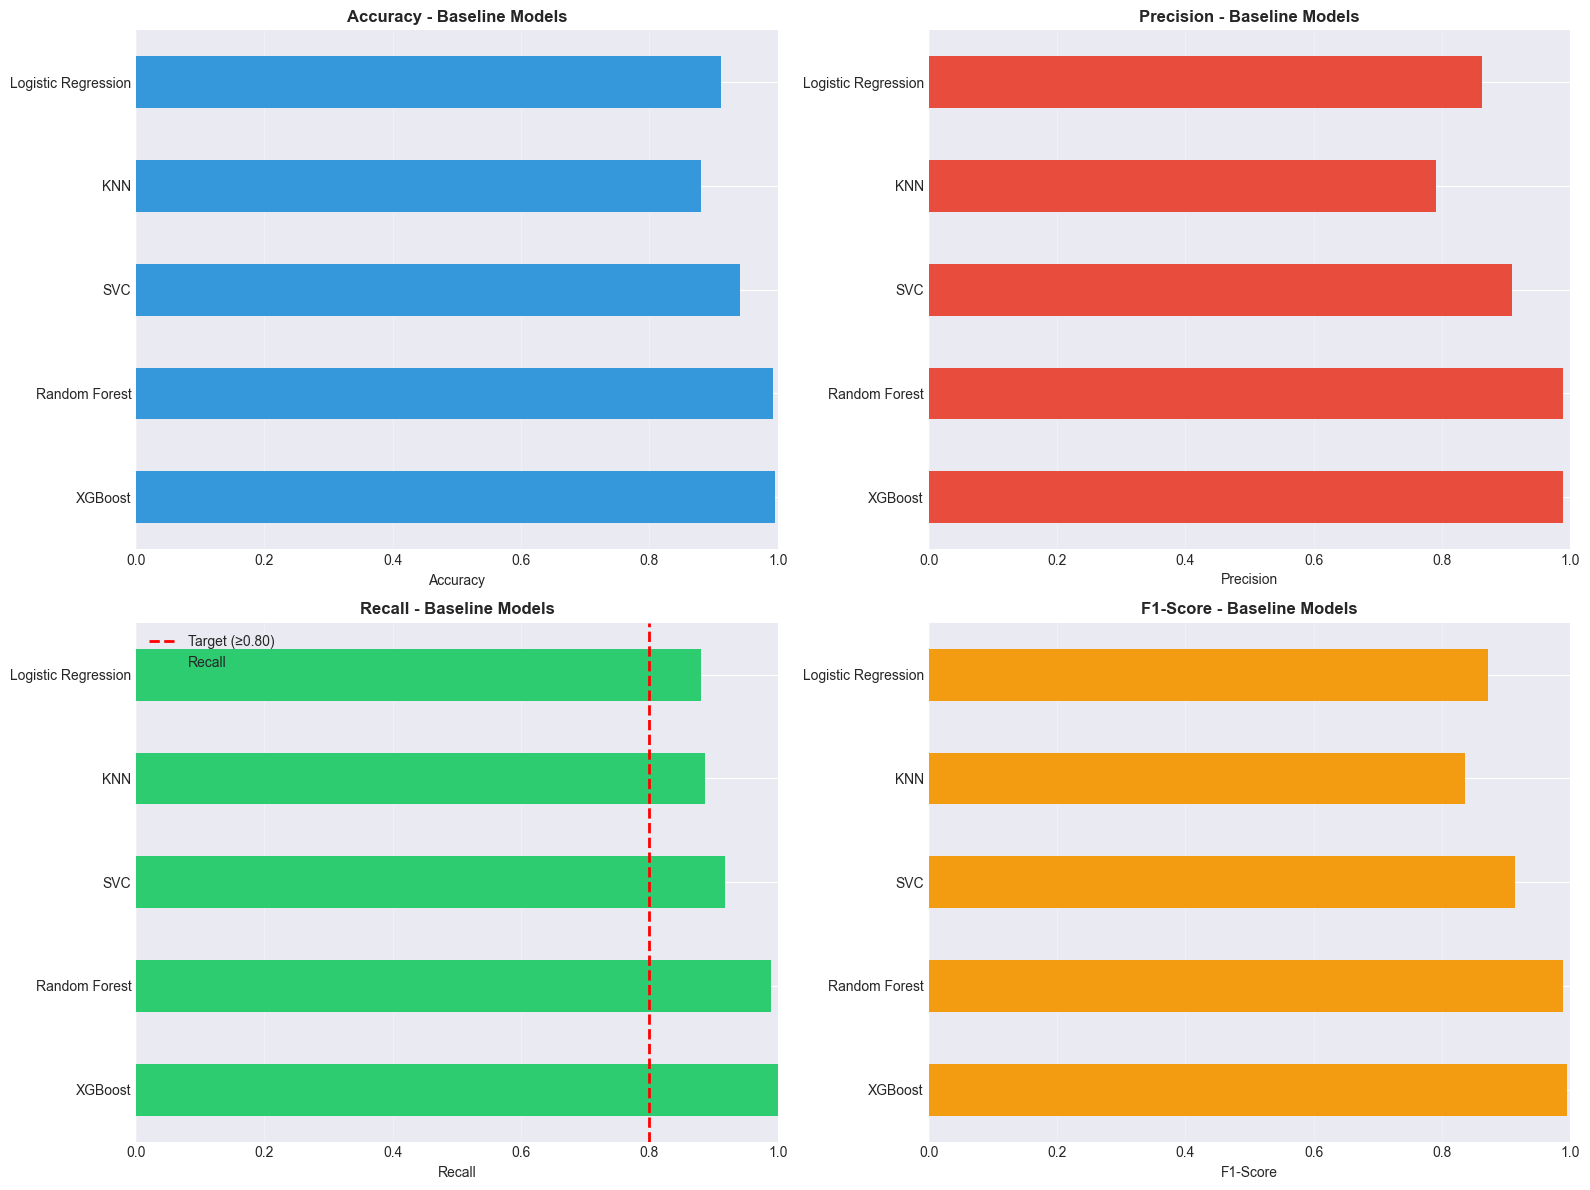

In [18]:
# Visualize baseline performance
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    ax = axes[idx // 2, idx % 2]
    
    comparison_df.plot(x='Model', y=metric, kind='barh', ax=ax, 
                       color=color, legend=False)
    
    ax.set_title(f'{metric} - Baseline Models', fontweight='bold', fontsize=12)
    ax.set_xlabel(metric)
    ax.set_ylabel('')
    
    #add threshold line for recall
    if metric == 'Recall':
        ax.axvline(x=0.80, color='red', linestyle='--', linewidth=2, 
                   label='Target (≥0.80)')
        ax.legend()
    
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim([0, 1])

plt.tight_layout()
plt.show()

# Cross Validation Analysis 

In [19]:
#perform 5-fold stratified cross-validation 
print("Performing 5-fold stratified cross-validation..")
print("-"*70)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    print(f"\nCross-validating {name}...")
    
    #perform cross-validation for multiple metrics 
    cv_accuracy = cross_val_score(model, X_train, y_train, cv=cv, 
                                  scoring='accuracy', n_jobs=-1)
    cv_precision = cross_val_score(model, X_train, y_train, cv=cv, 
                                   scoring='precision', n_jobs=-1)
    cv_recall = cross_val_score(model, X_train, y_train, cv=cv, 
                                scoring='recall', n_jobs=-1)
    cv_f1 = cross_val_score(model, X_train, y_train, cv=cv, 
                            scoring='f1', n_jobs=-1)
    
    cv_results[name] = {
        'accuracy_mean': cv_accuracy.mean(),
        'accuracy_std': cv_accuracy.std(),
        'precision_mean': cv_precision.mean(),
        'precision_std': cv_precision.std(),
        'recall_mean': cv_recall.mean(),
        'recall_std': cv_recall.std(),
        'f1_mean': cv_f1.mean(),
        'f1_std': cv_f1.std()
    }
    
    print(f"  Recall: {cv_recall.mean():.4f} (±{cv_recall.std():.4f})")
    print(f"  F1:     {cv_f1.mean():.4f} (±{cv_f1.std():.4f})")

print("\n" + "-" * 70)
print("Cross-validation complete")

Performing 5-fold stratified cross-validation..
----------------------------------------------------------------------

Cross-validating Logistic Regression...
  Recall: 0.9143 (±0.0205)
  F1:     0.9208 (±0.0122)

Cross-validating Random Forest...
  Recall: 0.9950 (±0.0028)
  F1:     0.9954 (±0.0009)

Cross-validating XGBoost...
  Recall: 0.9915 (±0.0053)
  F1:     0.9943 (±0.0026)

Cross-validating SVC...
  Recall: 0.9639 (±0.0157)
  F1:     0.9625 (±0.0051)

Cross-validating KNN...
  Recall: 0.9462 (±0.0186)
  F1:     0.9201 (±0.0088)

----------------------------------------------------------------------
Cross-validation complete


In [20]:
#create CV results table
cv_df = pd.DataFrame(cv_results).T
cv_df = cv_df.sort_values('recall_mean', ascending=False)

print("\nCross-Validation Results (Sorted by Mean Recall):")
print("-" * 90)
print(cv_df.round(4).to_string())


Cross-Validation Results (Sorted by Mean Recall):
------------------------------------------------------------------------------------------
                     accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  recall_std  f1_mean  f1_std
Random Forest               0.9954        0.0009          0.9958         0.0041       0.9950      0.0028   0.9954  0.0009
XGBoost                     0.9943        0.0026          0.9972         0.0027       0.9915      0.0053   0.9943  0.0026
SVC                         0.9625        0.0048          0.9613         0.0070       0.9639      0.0157   0.9625  0.0051
KNN                         0.9179        0.0085          0.8957         0.0094       0.9462      0.0186   0.9201  0.0088
Logistic Regression         0.9214        0.0114          0.9274         0.0053       0.9143      0.0205   0.9208  0.0122


# Hyperparameter Tuning 

In [23]:
#Define hyperparameter grids for top 3 models based on recall
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga'],
        'max_iter': [1000]
    },
    
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    },
    
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7, 9],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0]
    },
    
    'SVC': {
        'C': [0.1, 1, 10, 100],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto', 0.001, 0.01]
    },
    
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski']
    }
}

print("Hyperparameter Search Spaces Defined:")
print("-" * 70)
for model_name, params in param_grids.items():
    n_combinations = np.prod([len(v) for v in params.values()])
    print(f"\n{model_name}:")
    print(f"  Parameters: {list(params.keys())}")
    print(f"  Total combinations: {n_combinations:,}")

Hyperparameter Search Spaces Defined:
----------------------------------------------------------------------

Logistic Regression:
  Parameters: ['C', 'penalty', 'solver', 'max_iter']
  Total combinations: 20

Random Forest:
  Parameters: ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'max_features']
  Total combinations: 216

XGBoost:
  Parameters: ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree']
  Total combinations: 432

SVC:
  Parameters: ['C', 'kernel', 'gamma']
  Total combinations: 32

KNN:
  Parameters: ['n_neighbors', 'weights', 'metric']
  Total combinations: 30


In [24]:
# Perform GridSearchCV for each model
# Using recall as primary scoring metric
print("\nPerforming Hyperparameter Tuning (GridSearchCV)...")
print("-" * 70)
print("Primary metric: Recall (minimize false negatives)")
print("CV folds: 5 (stratified)")

tuned_models = {}
tuning_results = {}

for name in models.keys():
    print(f"\nTuning {name}...")
    start_time = time.time()
    
    # Create fresh model instance
    if name == 'Logistic Regression':
        base_model = LogisticRegression(random_state=42)
    elif name == 'Random Forest':
        base_model = RandomForestClassifier(random_state=42, n_jobs=-1)
    elif name == 'XGBoost':
        base_model = XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)
    elif name == 'SVC':
        base_model = SVC(random_state=42, probability=True)
    else:  # KNN
        base_model = KNeighborsClassifier(n_jobs=-1)
    
    # GridSearchCV
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grids[name],
        scoring='recall',  # Primary metric
        cv=cv,
        n_jobs=-1,
        verbose=1
    )
    
    # Fit
    grid_search.fit(X_train, y_train)
    
    tuning_time = time.time() - start_time
    
    # Store results
    tuned_models[name] = grid_search.best_estimator_
    tuning_results[name] = {
        'best_params': grid_search.best_params_,
        'best_cv_score': grid_search.best_score_,
        'tuning_time': tuning_time
    }
    
    print(f"  Best CV Recall: {grid_search.best_score_:.4f}")
    print(f"  Best params: {grid_search.best_params_}")
    print(f"  Time: {tuning_time:.1f}s")

print("\n" + "-" * 70)
print("Hyperparameter tuning complete")


Performing Hyperparameter Tuning (GridSearchCV)...
----------------------------------------------------------------------
Primary metric: Recall (minimize false negatives)
CV folds: 5 (stratified)

Tuning Logistic Regression...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
  Best CV Recall: 0.9228
  Best params: {'C': 1, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}
  Time: 15.1s

Tuning Random Forest...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
  Best CV Recall: 0.9965
  Best params: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
  Time: 398.8s

Tuning XGBoost...
Fitting 5 folds for each of 432 candidates, totalling 2160 fits
  Best CV Recall: 0.9936
  Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.6}
  Time: 326.0s

Tuning SVC...
Fitting 5 folds for each of 32 candidates, totalling 160 fits
  Best CV Recall: 0.9

# Final Model Evaluation 

In [25]:
#Evaluate tuned models on test set
print("Evaluating Tuned Models on Test Set...")
print("-" * 70)

tuned_results = {}

for name, model in tuned_models.items():
    print(f"\nEvaluating {name}...")
    result = evaluate_model(model, X_train, y_train, X_test, y_test, name)
    tuned_results[name] = result
    
    print(f"  Accuracy:  {result['accuracy']:.4f}")
    print(f"  Precision: {result['precision']:.4f}")
    print(f"  Recall:    {result['recall']:.4f} {'1' if result['recall'] >= 0.80 else '0'}")
    print(f"  F1-Score:  {result['f1_score']:.4f}")
    print(f"  ROC-AUC:   {result['roc_auc']:.4f}" if result['roc_auc'] else "  ROC-AUC:   N/A")

print("\n" + "-" * 70)
print("Tuned model evaluation complete")

Evaluating Tuned Models on Test Set...
----------------------------------------------------------------------

Evaluating Logistic Regression...
  Accuracy:  0.9033
  Precision: 0.8438
  Recall:    0.8804 1
  F1-Score:  0.8617
  ROC-AUC:   0.9646

Evaluating Random Forest...
  Accuracy:  0.9907
  Precision: 0.9838
  Recall:    0.9891 1
  F1-Score:  0.9864
  ROC-AUC:   0.9996

Evaluating XGBoost...
  Accuracy:  0.9981
  Precision: 0.9946
  Recall:    1.0000 1
  F1-Score:  0.9973
  ROC-AUC:   0.9999

Evaluating SVC...
  Accuracy:  0.9461
  Precision: 0.9016
  Recall:    0.9457 1
  F1-Score:  0.9231
  ROC-AUC:   0.9908

Evaluating KNN...
  Accuracy:  0.9480
  Precision: 0.9105
  Recall:    0.9402 1
  F1-Score:  0.9251
  ROC-AUC:   0.9820

----------------------------------------------------------------------
Tuned model evaluation complete


In [26]:
# Create final comparison table
final_comparison = pd.DataFrame({
    'Model': [r['model_name'] for r in tuned_results.values()],
    'Accuracy': [r['accuracy'] for r in tuned_results.values()],
    'Precision': [r['precision'] for r in tuned_results.values()],
    'Recall': [r['recall'] for r in tuned_results.values()],
    'F1-Score': [r['f1_score'] for r in tuned_results.values()],
    'ROC-AUC': [r['roc_auc'] if r['roc_auc'] else 0 for r in tuned_results.values()],
    'PR-AUC': [r['pr_auc'] if r['pr_auc'] else 0 for r in tuned_results.values()],
    'Train_Time': [r['train_time'] for r in tuned_results.values()]
})

# Sort by recall
final_comparison = final_comparison.sort_values('Recall', ascending=False)

print("\nFinal Model Comparison - Tuned Models (Sorted by Recall):")
print("-" * 90)
print(final_comparison.to_string(index=False))

# Identify best model
best_model_name = final_comparison.iloc[0]['Model']
best_recall = final_comparison.iloc[0]['Recall']

print("\n" + "=" * 90)
print(f"BEST MODEL: {best_model_name}")
print(f"Recall: {best_recall:.4f} {'(Target Met )' if best_recall >= 0.80 else '(Below Target )'}")
print("-" * 90)


Final Model Comparison - Tuned Models (Sorted by Recall):
------------------------------------------------------------------------------------------
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC   PR-AUC  Train_Time
            XGBoost  0.998141   0.994595 1.000000  0.997290 0.999939 0.999882    0.133133
      Random Forest  0.990706   0.983784 0.989130  0.986450 0.999585 0.999196    0.259083
                SVC  0.946097   0.901554 0.945652  0.923077 0.990835 0.983493    0.818953
                KNN  0.947955   0.910526 0.940217  0.925134 0.982007 0.970270    0.001984
Logistic Regression  0.903346   0.843750 0.880435  0.861702 0.964597 0.943437    2.269598

BEST MODEL: XGBoost
Recall: 1.0000 (Target Met )
------------------------------------------------------------------------------------------


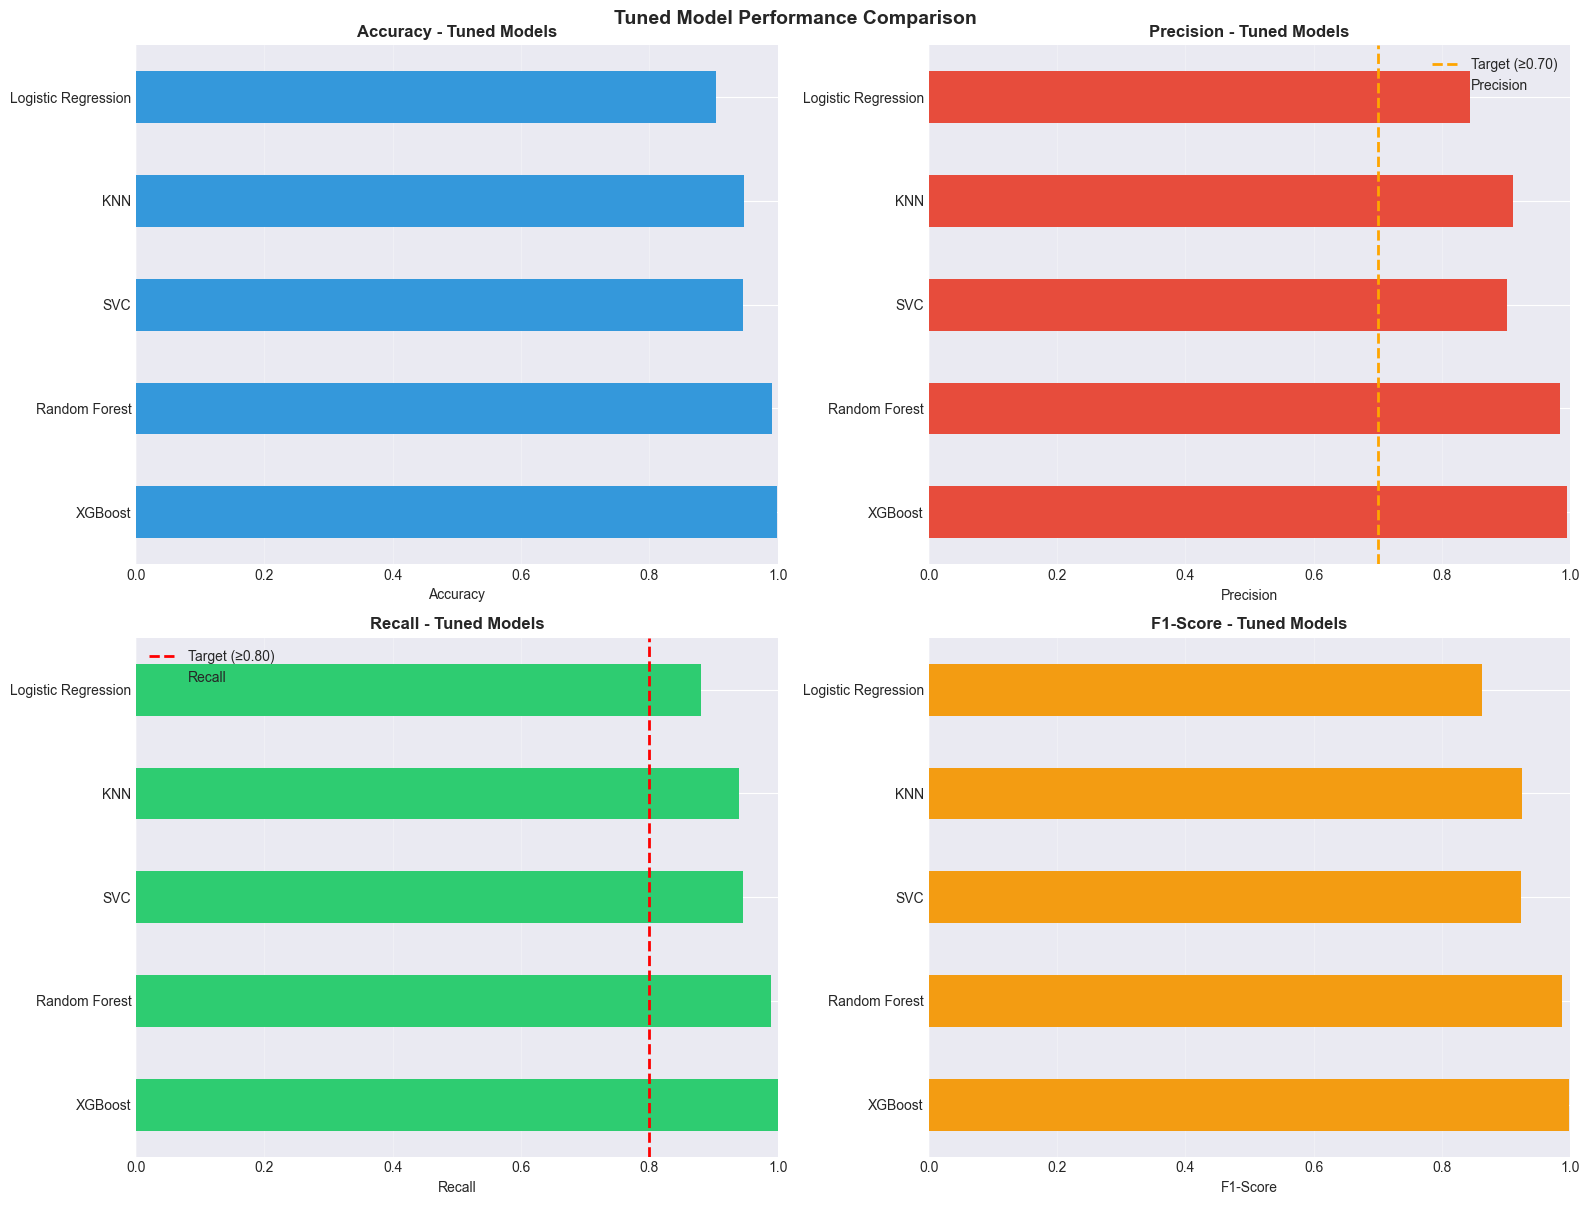

In [27]:
# Visualize final performance comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    ax = axes[idx // 2, idx % 2]
    
    final_comparison.plot(x='Model', y=metric, kind='barh', ax=ax, 
                          color=color, legend=False)
    
    ax.set_title(f'{metric} - Tuned Models', fontweight='bold', fontsize=12)
    ax.set_xlabel(metric)
    ax.set_ylabel('')
    
    # Add threshold lines
    if metric == 'Recall':
        ax.axvline(x=0.80, color='red', linestyle='--', linewidth=2, 
                   label='Target (≥0.80)')
        ax.legend()
    elif metric == 'Precision':
        ax.axvline(x=0.70, color='orange', linestyle='--', linewidth=2,
                   label='Target (≥0.70)')
        ax.legend()
    
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim([0, 1])

plt.tight_layout()
plt.suptitle('Tuned Model Performance Comparison', fontsize=14, fontweight='bold', y=1.00)
plt.show()

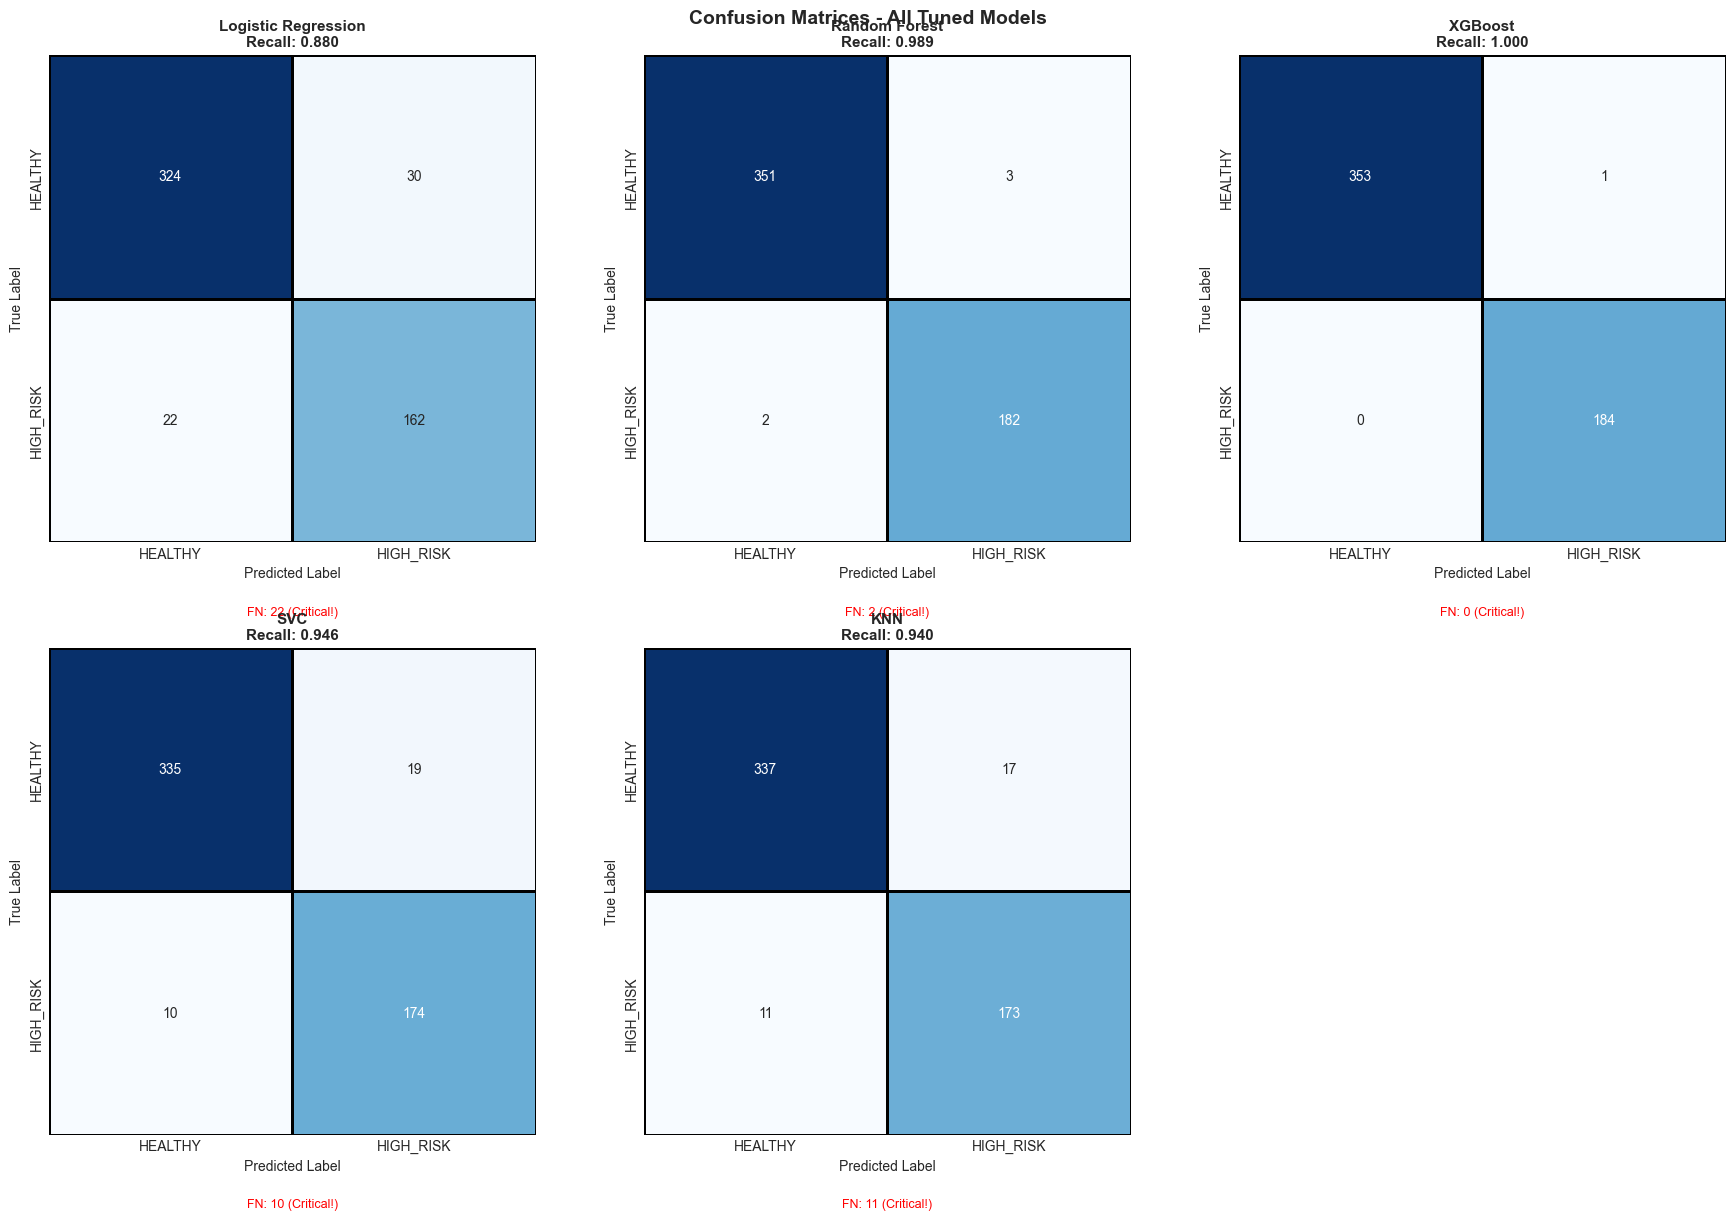

In [28]:
#plot confussion matrices for all tuned models 
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, result) in enumerate(tuned_results.items()):
    cm = result['confusion_matrix']
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                cbar=False, square=True, linewidths=1, linecolor='black')
    
    axes[idx].set_title(f'{name}\nRecall: {result["recall"]:.3f}', 
                       fontweight='bold', fontsize=11)
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xticklabels(['HEALTHY', 'HIGH_RISK'])
    axes[idx].set_yticklabels(['HEALTHY', 'HIGH_RISK'])
    
    # Add text annotations
    tn, fp, fn, tp = result['tn'], result['fp'], result['fn'], result['tp']
    textstr = f'FN: {fn} (Critical!)'
    axes[idx].text(0.5, -0.15, textstr, transform=axes[idx].transAxes,
                  fontsize=9, color='red', ha='center')

# Remove extra subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.suptitle('Confusion Matrices - All Tuned Models', fontsize=14, fontweight='bold', y=1.00)
plt.show()

In [30]:
# Detailed confusion matrix analysis for best model
best_result = tuned_results[best_model_name]

print(f"\nDetailed Analysis - {best_model_name}:")
print("-" * 70)
print("\nConfusion Matrix:")
print(best_result['confusion_matrix'])

tn, fp, fn, tp = best_result['tn'], best_result['fp'], best_result['fn'], best_result['tp']

print(f"\nBreakdown:")
print(f"  True Negatives (TN):  {tn} - Correctly identified HEALTHY banks")
print(f"  False Positives (FP): {fp} - HEALTHY banks flagged as HIGH_RISK (Type I error)")
print(f"  False Negatives (FN): {fn} - HIGH_RISK banks missed (Type II error - CRITICAL!)")
print(f"  True Positives (TP):  {tp} - Correctly identified HIGH_RISK banks")

print(f"\nPerformance Metrics:")
print(f"  Recall (Sensitivity):     {best_result['recall']:.4f} - {tp}/{tp+fn} high-risk banks caught")
print(f"  Precision (PPV):          {best_result['precision']:.4f} - {tp}/{tp+fp} flagged banks truly high-risk")
print(f"  Specificity:              {tn/(tn+fp):.4f} - {tn}/{tn+fp} healthy banks correctly identified")
print(f"  False Negative Rate:      {fn/(tp+fn):.4f} - {fn}/{tp+fn} high-risk banks missed")
print(f"  False Positive Rate:      {fp/(tn+fp):.4f} - {fp}/{tn+fp} healthy banks flagged")




Detailed Analysis - XGBoost:
----------------------------------------------------------------------

Confusion Matrix:
[[353   1]
 [  0 184]]

Breakdown:
  True Negatives (TN):  353 - Correctly identified HEALTHY banks
  False Positives (FP): 1 - HEALTHY banks flagged as HIGH_RISK (Type I error)
  False Negatives (FN): 0 - HIGH_RISK banks missed (Type II error - CRITICAL!)
  True Positives (TP):  184 - Correctly identified HIGH_RISK banks

Performance Metrics:
  Recall (Sensitivity):     1.0000 - 184/184 high-risk banks caught
  Precision (PPV):          0.9946 - 184/185 flagged banks truly high-risk
  Specificity:              0.9972 - 353/354 healthy banks correctly identified
  False Negative Rate:      0.0000 - 0/184 high-risk banks missed
  False Positive Rate:      0.0028 - 1/354 healthy banks flagged


# ROC and Precision-Recall Curves 

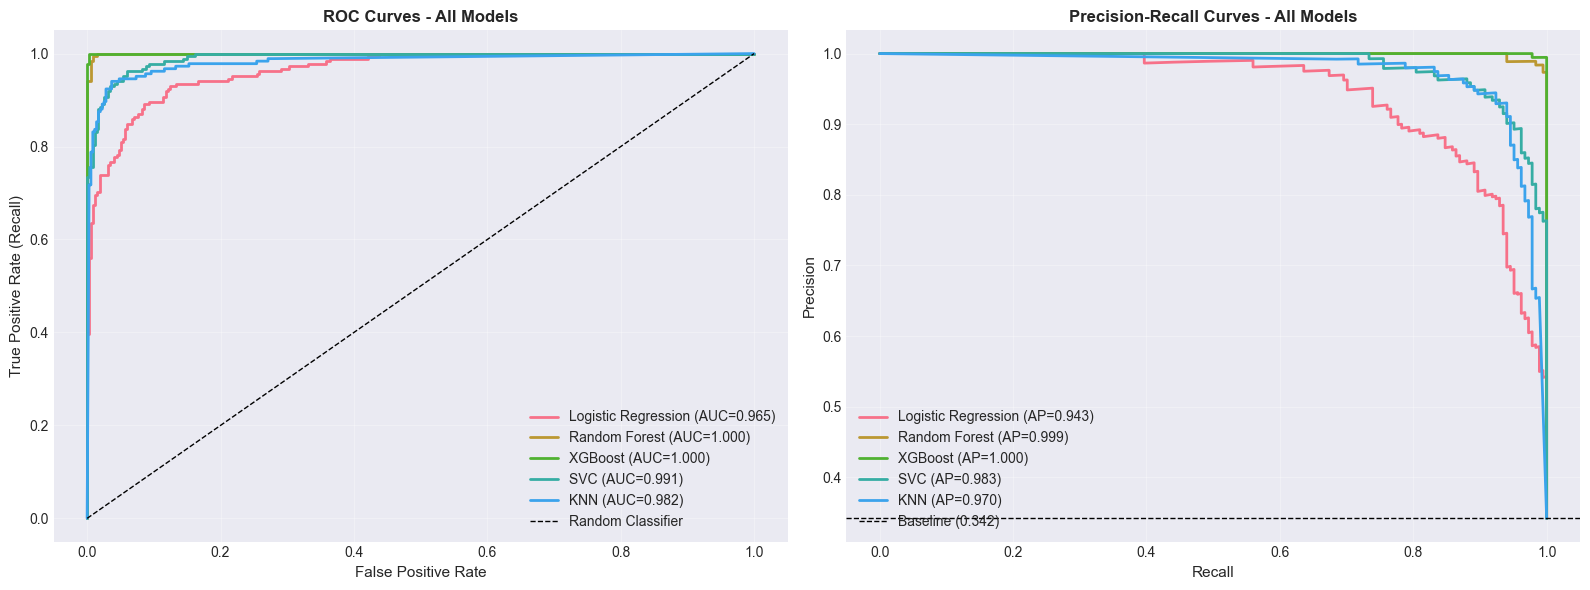

In [31]:
# Plot ROC curves for all models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
for name, result in tuned_results.items():
    if result['y_pred_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, result['y_pred_proba'])
        axes[0].plot(fpr, tpr, linewidth=2, 
                    label=f"{name} (AUC={result['roc_auc']:.3f})")

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate (Recall)', fontsize=11)
axes[0].set_title('ROC Curves - All Models', fontweight='bold', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Precision-Recall Curve
for name, result in tuned_results.items():
    if result['y_pred_proba'] is not None:
        precision, recall, _ = precision_recall_curve(y_test, result['y_pred_proba'])
        axes[1].plot(recall, precision, linewidth=2,
                    label=f"{name} (AP={result['pr_auc']:.3f})")

# Baseline (random classifier)
baseline_precision = y_test.sum() / len(y_test)
axes[1].axhline(y=baseline_precision, color='k', linestyle='--', linewidth=1,
               label=f'Baseline ({baseline_precision:.3f})')

axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall Curves - All Models', fontweight='bold', fontsize=12)
axes[1].legend(loc='lower left')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Classification Reports 

In [32]:
# Print classification reports for all models
for name, result in tuned_results.items():
    print(f"\nClassification Report - {name}:")
    print("-" * 70)
    print(classification_report(y_test, result['y_pred'], 
                                target_names=['HEALTHY', 'HIGH_RISK'],
                                digits=4))
    print("-" * 70)


Classification Report - Logistic Regression:
----------------------------------------------------------------------
              precision    recall  f1-score   support

     HEALTHY     0.9364    0.9153    0.9257       354
   HIGH_RISK     0.8438    0.8804    0.8617       184

    accuracy                         0.9033       538
   macro avg     0.8901    0.8978    0.8937       538
weighted avg     0.9047    0.9033    0.9038       538

----------------------------------------------------------------------

Classification Report - Random Forest:
----------------------------------------------------------------------
              precision    recall  f1-score   support

     HEALTHY     0.9943    0.9915    0.9929       354
   HIGH_RISK     0.9838    0.9891    0.9864       184

    accuracy                         0.9907       538
   macro avg     0.9891    0.9903    0.9897       538
weighted avg     0.9907    0.9907    0.9907       538

-----------------------------------------------

# SHap Analysis (Model Interpretation)

In [34]:
# SHAP analysis for best model
print(f"\nGenerating SHAP values for {best_model_name}...")
print("This may take a few minutes...\n")

X_test_sample = X_test[:100]  # Use first 100 test samples

# Create SHAP explainer based on model type
if best_model_name in ['Random Forest', 'XGBoost']:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_sample)
    
    # For binary classification, get SHAP values for positive class
    if isinstance(shap_values, list):
        shap_values_plot = shap_values[1]
    else:
        shap_values_plot = shap_values
else:
    # For other models, use KernelExplainer
    explainer = shap.KernelExplainer(best_model.predict_proba, 
                                     shap.sample(X_train, 100))
    shap_values = explainer.shap_values(X_test_sample)
    shap_values_plot = shap_values[1] if isinstance(shap_values, list) else shap_values

print("SHAP values computed successfully")


Generating SHAP values for XGBoost...
This may take a few minutes...

SHAP values computed successfully


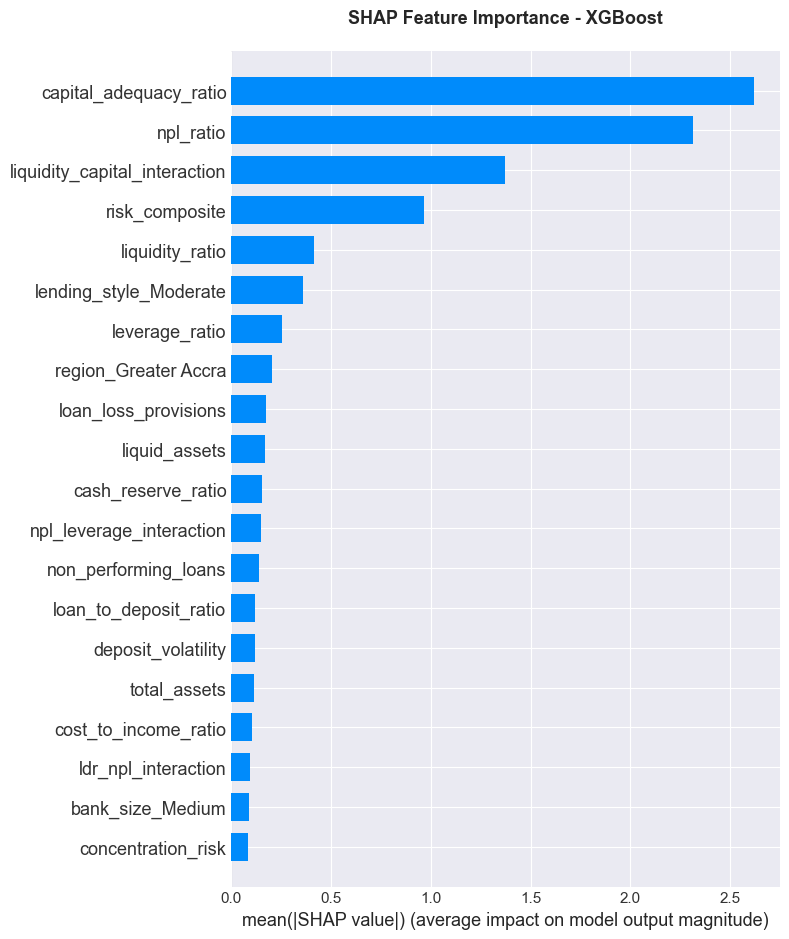

In [37]:
# SHAP Summary Plot
feature_names = pd.read_csv(f'{data_dir}/feature_names.csv')
feature_names = feature_names.squeeze().tolist()

fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values_plot, X_test_sample, 
                 feature_names=feature_names, 
                 plot_type='bar', show=False, max_display=20)
plt.title(f'SHAP Feature Importance - {best_model_name}', 
         fontweight='bold', fontsize=13, pad=20)
plt.tight_layout()
plt.show()

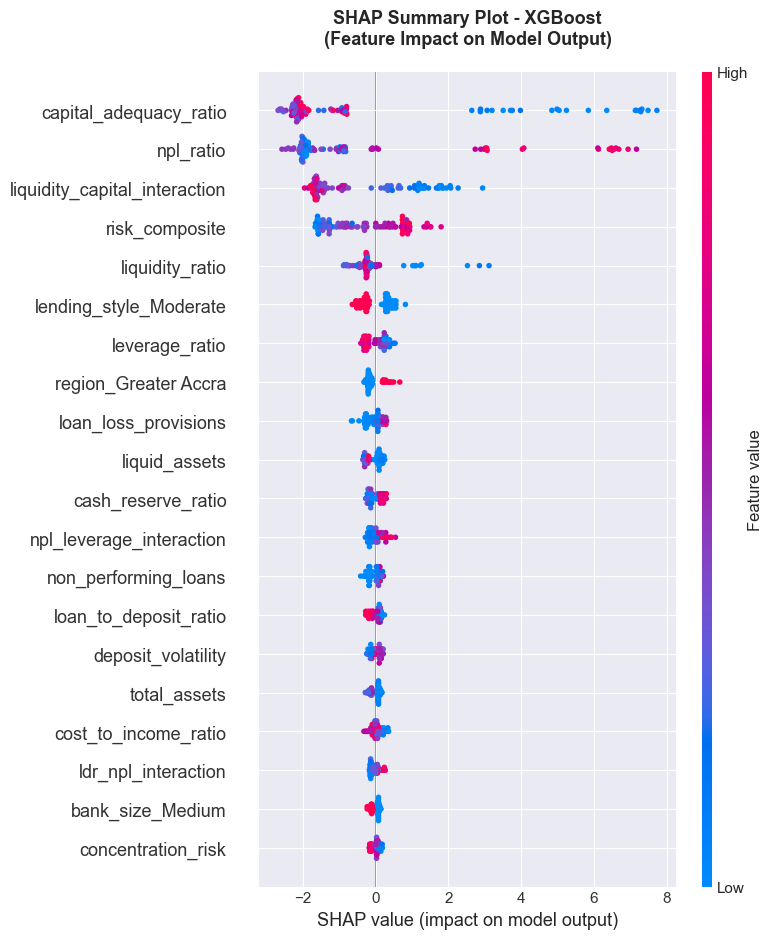

In [38]:
# SHAP Summary Plot (detailed)
fig, ax = plt.subplots(figsize=(12, 10))
shap.summary_plot(shap_values_plot, X_test_sample, 
                 feature_names=feature_names, 
                 show=False, max_display=20)
plt.title(f'SHAP Summary Plot - {best_model_name}\n(Feature Impact on Model Output)', 
         fontweight='bold', fontsize=13, pad=20)
plt.tight_layout()
plt.show()

# Save Best Model

In [40]:
# Create models directory
import os
models_dir = 'models'
os.makedirs(models_dir, exist_ok=True)

# Save best model
best_model_path = f'{models_dir}/best_model.pkl'
joblib.dump(best_model, best_model_path)
print(f"Best model saved: {best_model_path}")

# Save all tuned models
for name, model in tuned_models.items():
    model_path = f'{models_dir}/{name.replace(" ", "_").lower()}_tuned.pkl'
    joblib.dump(model, model_path)
    print(f"Saved: {model_path}")

# Save model performance metrics
final_comparison.to_csv(f'{models_dir}/model_comparison.csv', index=False)
print(f"\nModel comparison saved: {models_dir}/model_comparison.csv")

# Save best model details
best_model_info = {
    'model_name': best_model_name,
    'best_params': tuning_results[best_model_name]['best_params'],
    'test_metrics': {
        'accuracy': best_result['accuracy'],
        'precision': best_result['precision'],
        'recall': best_result['recall'],
        'f1_score': best_result['f1_score'],
        'roc_auc': best_result['roc_auc']
    },
    'confusion_matrix': {
        'tn': int(best_result['tn']),
        'fp': int(best_result['fp']),
        'fn': int(best_result['fn']),
        'tp': int(best_result['tp'])
    }
}

import json
with open(f'{models_dir}/best_model_info.json', 'w') as f:
    json.dump(best_model_info, f, indent=4)
print(f"Best model info saved: {models_dir}/best_model_info.json")

Best model saved: models/best_model.pkl
Saved: models/logistic_regression_tuned.pkl
Saved: models/random_forest_tuned.pkl
Saved: models/xgboost_tuned.pkl
Saved: models/svc_tuned.pkl
Saved: models/knn_tuned.pkl

Model comparison saved: models/model_comparison.csv
Best model info saved: models/best_model_info.json
